# Aproximación Gaussiana de Curvas — Primer Intento

Este notebook explora si el modelo gaussiano puede representar las curvas del dataset.
Es un **primer intento**: ajustamos una sola campana gaussiana a cada curva y evaluamos qué tan bien funciona.

## El modelo

$$y = A \cdot e^{-\frac{(x - \mu)^2}{2\sigma^2}} + c$$

| Parámetro | Significado |
|-----------|-------------|
| **A** | Amplitud (altura del pico) |
| **μ** | Centro del pico (media) |
| **σ** | Dispersión (ancho de la campana) |
| **c** | Offset o línea base |

El ajuste se realiza por **mínimos cuadrados no lineales** usando `scipy.optimize.curve_fit`,
que minimiza $\sum (y_{obs} - y_{modelo})^2$.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100})

In [10]:
BASE_DIR   = Path('../..')
TARGET_DIR = BASE_DIR / 'datos' / 'target'

COLORES = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0']

# 5 curvas aleatorias reproducibles
np.random.seed(42)
CURVA_IDS = sorted(np.random.choice(range(1, 501), 5, replace=False).tolist())

def cargar_curva(curve_id):
    path = TARGET_DIR / f'curve_{curve_id:04d}.txt'
    data = np.loadtxt(path, delimiter=',')
    return data[:, 0], data[:, 1]

print(f"{'Curva':>6}  {'N pts':>6}  {'X min':>8}  {'X max':>8}  {'Y min':>8}  {'Y max':>8}")
print('-' * 55)
for cid in CURVA_IDS:
    x, y = cargar_curva(cid)
    print(f"{cid:>6}  {len(x):>6}  {x.min():>8.2f}  {x.max():>8.2f}  {y.min():>8.2f}  {y.max():>8.2f}")

 Curva   N pts     X min     X max     Y min     Y max
-------------------------------------------------------
    74    8000      4.55    231.29     14.22     79.03
   105    8000     17.01    257.50     34.72    103.49
   156    8000      5.52    153.86     11.41     73.38
   362    8000     10.79    154.05      8.89     89.65
   375    8000     17.49    184.98     14.23    102.46


## Funciones del modelo

1. La función gaussiana
2. Estimador de parámetros iniciales `p0` — crítico para que `curve_fit` converja
3. Wrapper que maneja errores de convergencia

In [11]:
def gaussiana(x, A, mu, sigma, c):
    """y = A * exp(-((x - mu)^2) / (2 * sigma^2)) + c"""
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) + c


def estimar_p0(x, y):
    """
    Estima p0 = [A, mu, sigma, c] a partir de los datos.
      c  = min(y)             → línea base
      A  = max(y) - min(y)   → amplitud
      mu = x donde y es máx  → centro
      sigma via FWHM / 2.355 → ancho
    """
    c  = float(np.min(y))
    ys = y - c
    A  = float(np.max(ys))
    mu = float(x[np.argmax(ys)])

    half = A / 2
    idx_above = np.where(ys >= half)[0]
    if len(idx_above) >= 2:
        sigma = float((x[idx_above[-1]] - x[idx_above[0]]) / 2.355)
    else:
        sigma = float((x.max() - x.min()) / 6)

    return [A, mu, max(sigma, 1e-6), c]


def ajustar_gaussiana(x, y, maxfev=50000):
    p0 = estimar_p0(x, y)
    try:
        popt, _ = curve_fit(gaussiana, x, y, p0=p0, maxfev=maxfev)
        y_pred  = gaussiana(x, *popt)
        return {
            'exito': True,
            'A': popt[0], 'mu': popt[1], 'sigma': popt[2], 'c': popt[3],
            'r2':   r2_score(y, y_pred),
            'rmse': float(np.sqrt(mean_squared_error(y, y_pred))),
            'y_pred': y_pred,
        }
    except RuntimeError as e:
        return {'exito': False, 'error': str(e)}

## Ajuste individual — 5 curvas al azar

Para cada curva: datos reales vs. gaussiana ajustada / residuales / parámetros.

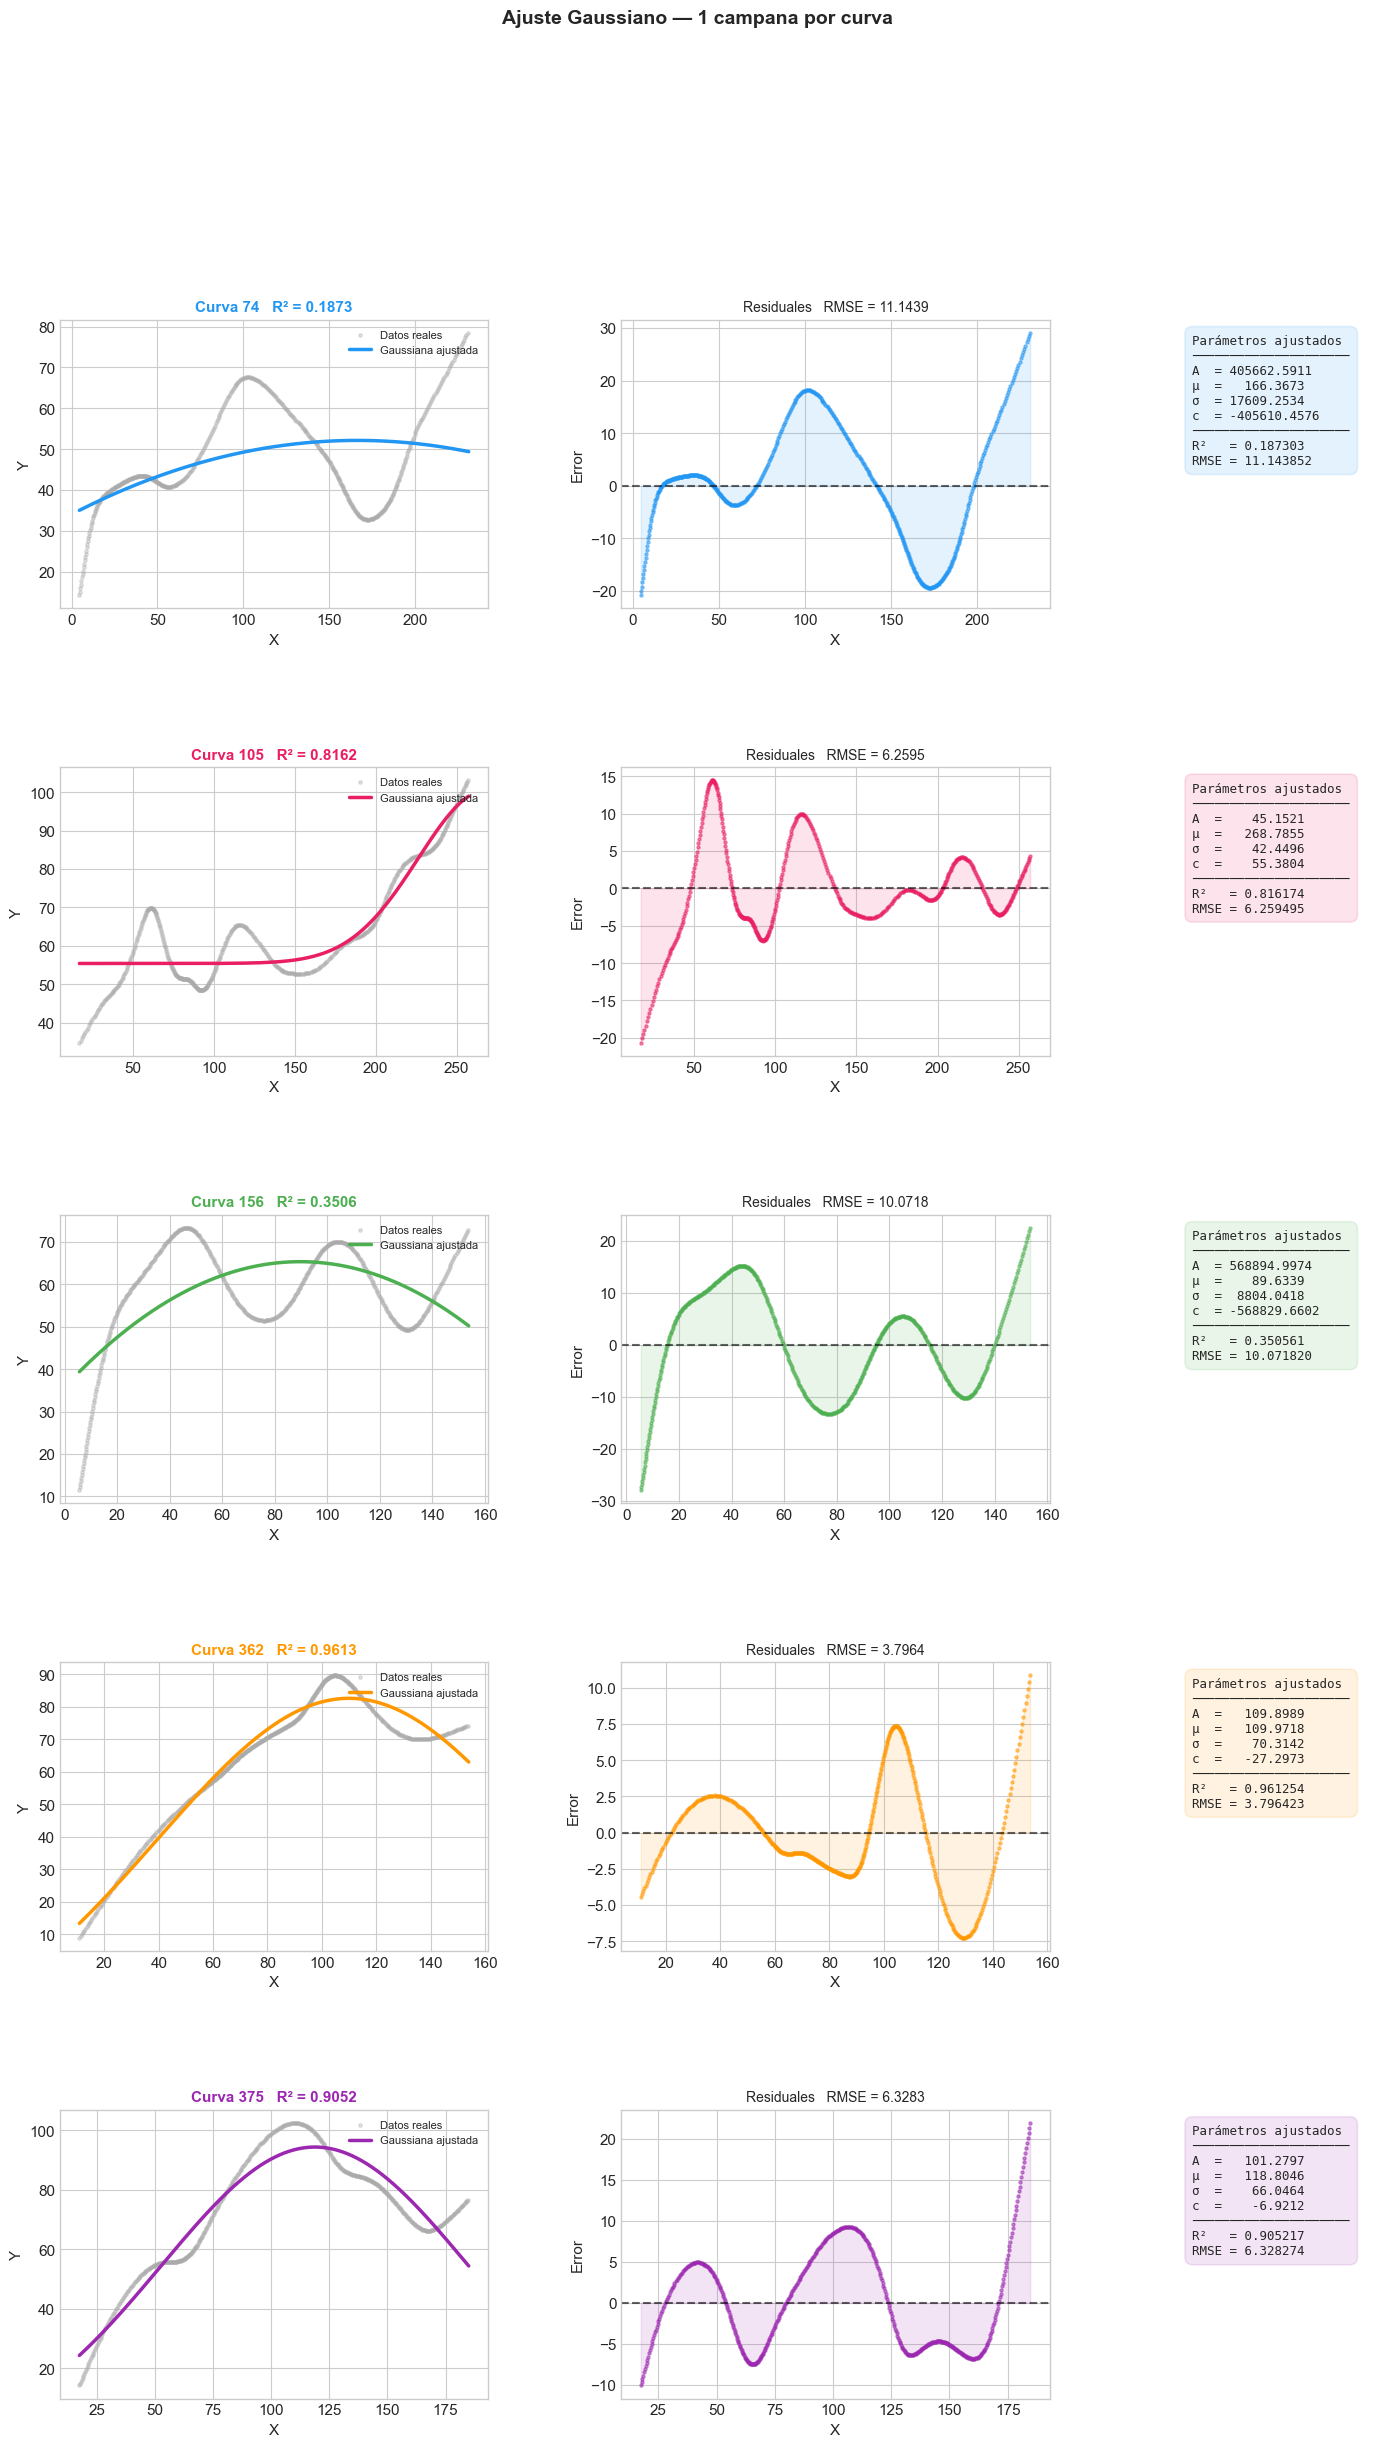

In [ ]:
resultados = {}

fig = plt.figure(figsize=(17, 27))
fig.suptitle('Ajuste Gaussiano — 1 campana por curva',
             fontsize=14, fontweight='bold', y=0.995)

outer = gridspec.GridSpec(5, 1, figure=fig, hspace=0.55)

for i, cid in enumerate(CURVA_IDS):
    x, y  = cargar_curva(cid)
    res   = ajustar_gaussiana(x, y)
    resultados[cid] = res
    color = COLORES[i]
    idx   = np.arange(0, len(x), 16)   # ~500 pts para scatter

    inner = gridspec.GridSpecFromSubplotSpec(
        1, 3, subplot_spec=outer[i], wspace=0.38, width_ratios=[2.2, 2.2, 1.0]
    )
    ax_fit  = fig.add_subplot(inner[0])
    ax_res  = fig.add_subplot(inner[1])
    ax_info = fig.add_subplot(inner[2])

    # datos + ajuste
    ax_fit.scatter(x[idx], y[idx], s=6, alpha=0.35, color='#aaaaaa',
                   label='Datos reales', zorder=2)
    if res['exito']:
        ax_fit.plot(x, res['y_pred'], color=color, lw=2.5,
                    label='Gaussiana ajustada', zorder=3)
        ax_fit.set_title(f"Curva {cid}   R² = {res['r2']:.4f}",
                         fontsize=11, fontweight='bold', color=color)
    else:
        ax_fit.set_title(f"Curva {cid}   ajuste fallido",
                         fontsize=11, fontweight='bold', color='#c62828')
    ax_fit.set_xlabel('X')
    ax_fit.set_ylabel('Y')
    ax_fit.legend(fontsize=8, loc='upper right')

    # residuales
    if res['exito']:
        residuales = y[idx] - res['y_pred'][idx]
        ax_res.scatter(x[idx], residuales, s=5, alpha=0.5, color=color)
        ax_res.axhline(0, color='black', lw=1.5, linestyle='--', alpha=0.6)
        ax_res.fill_between(x[idx], residuales, 0, alpha=0.12, color=color)
        ax_res.set_title(f"Residuales   RMSE = {res['rmse']:.4f}", fontsize=10)
    else:
        ax_res.text(0.5, 0.5, 'sin ajuste', ha='center', va='center',
                    transform=ax_res.transAxes, color='#c62828')
        ax_res.set_title('Residuales', fontsize=10)
    ax_res.set_xlabel('X')
    ax_res.set_ylabel('Error')

    # parámetros
    ax_info.axis('off')
    if res['exito']:
        texto = (
            f"Parámetros ajustados\n"
            f"{'─'*21}\n"
            f"A  = {res['A']:>10.4f}\n"
            f"μ  = {res['mu']:>10.4f}\n"
            f"σ  = {res['sigma']:>10.4f}\n"
            f"c  = {res['c']:>10.4f}\n"
            f"{'─'*21}\n"
            f"R²   = {res['r2']:.6f}\n"
            f"RMSE = {res['rmse']:.6f}"
        )
    else:
        texto = f"Error:\n{res['error'][:80]}"
    ax_info.text(0.05, 0.95, texto, transform=ax_info.transAxes,
                 fontsize=9, va='top', ha='left', fontfamily='monospace',
                 bbox=dict(boxstyle='round,pad=0.6', facecolor=color,
                           alpha=0.12, edgecolor=color, linewidth=1.2))

plt.show()

## Resumen de las 5 curvas

,R²,RMSE,A,μ,σ,c,ok
Curva,,,,,,,
74,0.187303,11.143852,405662.5911,166.3673,17609.2534,-405610.4576,✓
105,0.816174,6.259495,45.1521,268.7855,42.4496,55.3804,✓
156,0.350561,10.071820,568894.9974,89.6339,8804.0418,-568829.6602,✓
362,0.961254,3.796423,109.8989,109.9718,70.3142,-27.2973,✓
375,0.905217,6.328274,101.2797,118.8046,66.0464,-6.9212,✓


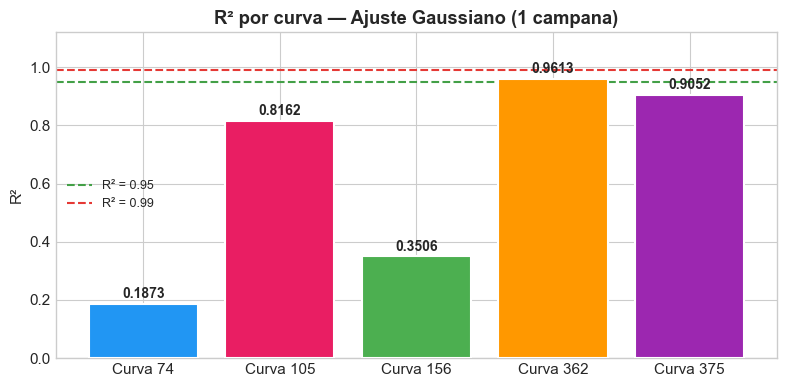

In [13]:
filas = []
for cid, res in resultados.items():
    filas.append({
        'Curva': cid,
        'R²':    round(res['r2'],    6) if res['exito'] else None,
        'RMSE':  round(res['rmse'],  6) if res['exito'] else None,
        'A':     round(res['A'],     4) if res['exito'] else None,
        'μ':     round(res['mu'],    4) if res['exito'] else None,
        'σ':     round(res['sigma'], 4) if res['exito'] else None,
        'c':     round(res['c'],     4) if res['exito'] else None,
        'ok':    '✓' if res['exito'] else '✗',
    })

df_muestras = pd.DataFrame(filas).set_index('Curva')
display(df_muestras)

fig, ax = plt.subplots(figsize=(8, 4))
labels  = [f"Curva {cid}" for cid in resultados]
r2_vals = [res['r2'] if res['exito'] else 0.0 for res in resultados.values()]
bars    = ax.bar(labels, r2_vals, color=COLORES, edgecolor='white', lw=1.5, zorder=3)

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0.95, color='#43A047', linestyle='--', lw=1.5, label='R² = 0.95', zorder=2)
ax.axhline(0.99, color='#E53935', linestyle='--', lw=1.5, label='R² = 0.99', zorder=2)
ax.set_ylim(0, 1.12)
ax.set_ylabel('R²')
ax.set_title('R² por curva — Ajuste Gaussiano (1 campana)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Ajuste sobre las 500 curvas

Probamos el modelo gaussiano en todo el dataset y vemos cómo se distribuye el R².

In [14]:
registros = []

for cid in range(1, 501):
    x, y = cargar_curva(cid)
    # submuestreamos para velocidad (1 de cada 8 → ~1000 pts)
    xs, ys = x[::8], y[::8]
    res = ajustar_gaussiana(xs, ys, maxfev=10000)
    registros.append({
        'curva': cid,
        'exito': res['exito'],
        'r2':    res['r2']   if res['exito'] else np.nan,
        'rmse':  res['rmse'] if res['exito'] else np.nan,
        'A':     res['A']    if res['exito'] else np.nan,
        'mu':    res['mu']   if res['exito'] else np.nan,
        'sigma': res['sigma']if res['exito'] else np.nan,
        'c':     res['c']    if res['exito'] else np.nan,
    })
    if cid % 100 == 0:
        print(f"{cid}/500", end='   ', flush=True)

df_all = pd.DataFrame(registros)
r2_ok  = df_all['r2'].dropna()

stats = pd.DataFrame({
    'Valor': [
        len(df_all),
        int(df_all['exito'].sum()),
        int((~df_all['exito']).sum()),
        round(r2_ok.mean(),   4),
        round(r2_ok.median(), 4),
        round(r2_ok.std(),    4),
        round(r2_ok.min(),    4),
        round(r2_ok.max(),    4),
        int((r2_ok > 0.90).sum()),
        int((r2_ok > 0.95).sum()),
        int((r2_ok > 0.99).sum()),
    ]
}, index=[
    'Total curvas',
    'Ajuste exitoso',
    'Ajuste fallido',
    'R² medio',
    'R² mediana',
    'R² std',
    'R² mínimo',
    'R² máximo',
    'R² > 0.90',
    'R² > 0.95',
    'R² > 0.99',
])
display(stats)

# Top 5 y bottom 5
print('\nMejores 5 ajustes:')
display(df_all.nlargest(5, 'r2')[['curva', 'r2', 'rmse', 'A', 'mu', 'sigma', 'c']].round(4))

print('\nPeores 5 ajustes (converge pero bajo R²):')
display(df_all.dropna().nsmallest(5, 'r2')[['curva', 'r2', 'rmse', 'A', 'mu', 'sigma', 'c']].round(4))

100/500   200/500   300/500   400/500   500/500   

,Valor
Total curvas,500.0000
Ajuste exitoso,483.0000
Ajuste fallido,17.0000
R² medio,0.7433
R² mediana,0.8172
R² std,0.2405
R² mínimo,0.0166
R² máximo,0.9999
R² > 0.90,172.0000
R² > 0.95,110.0000



Mejores 5 ajustes:


,curva,r2,rmse,A,mu,sigma,c
226,227,0.9999,0.1477,103.6723,49.5099,38.6399,-47.0005
412,413,0.9997,0.2498,51.1798,36.7435,17.3363,3.5116
114,115,0.9996,0.2120,35.1523,56.2964,27.2561,14.5427
416,417,0.9996,0.4557,101.5222,90.9387,46.8993,-21.9673
65,66,0.9990,0.7559,122.3009,103.6890,55.9243,-30.0579



Peores 5 ajustes (converge pero bajo R²):


,curva,r2,rmse,A,mu,sigma,c
170,171,0.0166,10.9189,33956.1375,164.4458,8627.5516,-33893.8754
50,51,0.0179,9.3720,66775.6904,146.0597,12293.2320,-66722.2534
387,388,0.0221,10.5233,-34160.9907,-112.6635,18007.8991,34212.1948
422,423,0.0303,7.5791,58927.7695,74.9589,4723.6355,-58883.2039
248,249,0.0400,9.7859,118891.5776,115.3367,9572.3435,-118835.8499


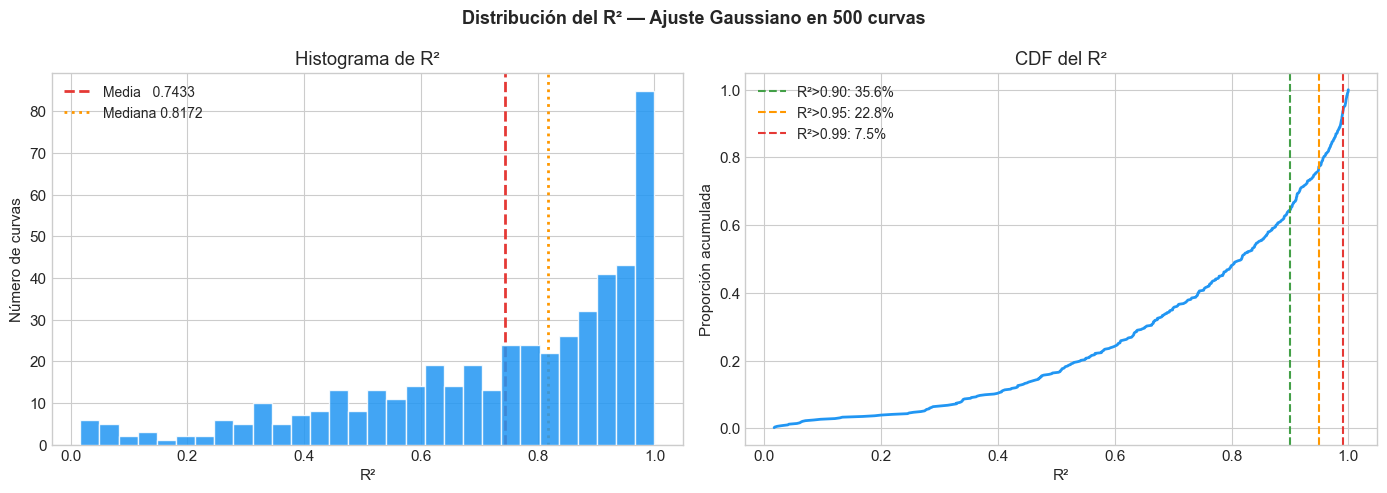

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución del R² — Ajuste Gaussiano en 500 curvas',
             fontsize=13, fontweight='bold')

# histograma
ax = axes[0]
ax.hist(r2_ok, bins=30, color='#2196F3', edgecolor='white', alpha=0.85, zorder=3)
ax.axvline(r2_ok.mean(),   color='#E53935', lw=2, linestyle='--',
           label=f"Media   {r2_ok.mean():.4f}")
ax.axvline(r2_ok.median(), color='#FF9800', lw=2, linestyle=':',
           label=f"Mediana {r2_ok.median():.4f}")
ax.set_xlabel('R²')
ax.set_ylabel('Número de curvas')
ax.set_title('Histograma de R²')
ax.legend(fontsize=10)

# CDF acumulada
ax2 = axes[1]
sorted_r2 = np.sort(r2_ok)
cdf       = np.arange(1, len(sorted_r2) + 1) / len(sorted_r2)
ax2.plot(sorted_r2, cdf, color='#2196F3', lw=2)
for thresh, col, ls in [(0.90, '#43A047', '--'), (0.95, '#FF9800', '--'), (0.99, '#E53935', '--')]:
    pct = float((r2_ok > thresh).mean()) * 100
    ax2.axvline(thresh, color=col, lw=1.5, linestyle=ls,
                label=f"R²>{thresh:.2f}: {pct:.1f}%")
ax2.set_xlabel('R²')
ax2.set_ylabel('Proporción acumulada')
ax2.set_title('CDF del R²')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

## Observaciones

**Limitaciones de una sola gaussiana:**

- Solo puede representar formas con **un único pico** — curvas con múltiples máximos o cambios de dirección quedarán mal ajustadas.
- El resultado depende fuertemente de los valores iniciales `p0`; malas estimaciones pueden llevar a no convergencia.
- R² bajo no significa que el modelo sea inútil: puede capturar tendencia global pero fallar en detalles.

**Posibles pasos siguientes:**

1. Suma de gaussianas para curvas con varios picos
2. Detección automática del número de picos con `scipy.signal.find_peaks`
3. Comparación directa con la aproximación polinomial